In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
trades = files.upload()

Saving historical_data.csv to historical_data.csv


In [5]:
from google.colab import files
sentiment = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv


In [3]:
trades = pd.read_csv("historical_data.csv")

In [6]:
sentiment = pd.read_csv("fear_greed_index.csv")

In [7]:
trades.head()
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [9]:
trades.isnull().sum()
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [10]:
trades.duplicated().sum()
sentiment.duplicated().sum()

np.int64(0)

# **Standardization**

In [11]:
trades.columns = trades.columns.str.lower()
sentiment.columns = sentiment.columns.str.lower()

In [12]:
print(trades.columns)
print(sentiment.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


# **Converting Trader Timestamp**

In [13]:
trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='ms')
trades['date'] = trades['timestamp'].dt.date

In [14]:
trades[['timestamp','date']].head()

,timestamp,date
0,2024-10-27 03:33:20,2024-10-27
1,2024-10-27 03:33:20,2024-10-27
2,2024-10-27 03:33:20,2024-10-27
3,2024-10-27 03:33:20,2024-10-27
4,2024-10-27 03:33:20,2024-10-27


In [15]:
print("Trades date range:", trades['date'].min(), "to", trades['date'].max())

Trades date range: 2023-03-28 to 2025-06-15


# **Handling Sentiment dataset**

In [16]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [17]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [18]:
print("Sentiment date range:", sentiment['date'].min(), "to", sentiment['date'].max())

Sentiment date range: 2018-02-01 to 2025-05-02


# **Merging Both Datasets**

In [19]:
data = trades.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

In [20]:
data = data.dropna(subset=['classification'])

In [21]:
data[['date','classification']].head(10)

,date,classification
0,2024-10-27,Greed
1,2024-10-27,Greed
2,2024-10-27,Greed
3,2024-10-27,Greed
4,2024-10-27,Greed
5,2024-10-27,Greed
6,2024-10-27,Greed
7,2024-10-27,Greed
8,2024-10-27,Greed
9,2024-10-27,Greed


In [22]:
data['classification'].value_counts()

,count
classification,
Fear,133871
Greed,36289
Neutral,7141
Extreme Greed,6962


#**Analysis**

### **Create Profit / Win Column**

In [23]:
data['win'] = data['closed pnl'] > 0

### **Daily PnL per trader**

In [24]:
daily_pnl = data.groupby(['account','date'])['closed pnl'].sum().reset_index()
daily_pnl.head()

,account,date,closed pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,-1.000000e+00


### **Win Rate per trader**

In [25]:
win_rate = data.groupby('account')['win'].mean().reset_index()
win_rate.head()

,account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.443031
2,0x271b280974205ca63b716753467d5a371de622ab,0.430192
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438112
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519790


### **Average PnL by Sentiment**

In [26]:
data.groupby('classification')['closed pnl'].mean().sort_values()

,closed pnl
classification,
Neutral,22.229713
Extreme Greed,25.418772
Fear,50.047622
Greed,87.894859


### **PnL vs Sentiment**

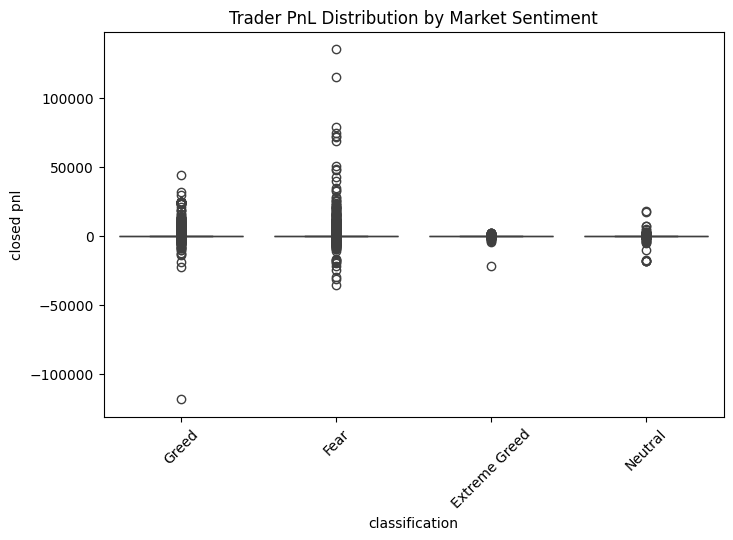

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='closed pnl', data=data)
plt.title("Trader PnL Distribution by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

### **Trader Behavior Change**

In [28]:
data.groupby('classification')['size usd'].mean()

,size usd
classification,
Extreme Greed,5660.265764
Fear,5259.977837
Greed,3182.883845
Neutral,3058.848110


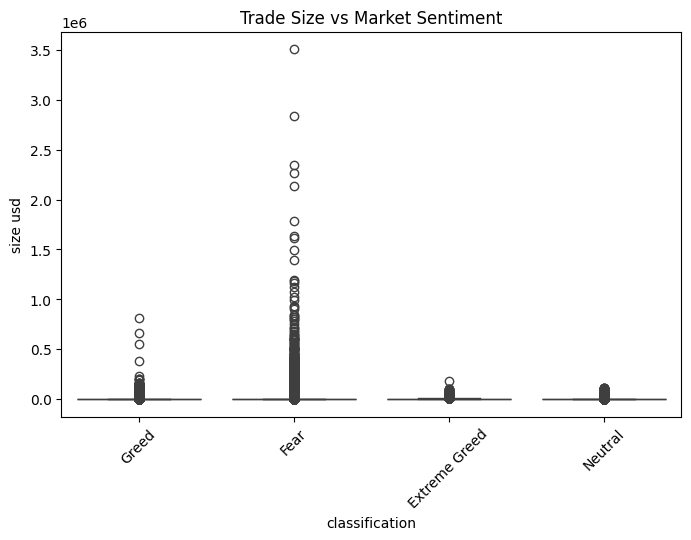

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='size usd', data=data)
plt.title("Trade Size vs Market Sentiment")
plt.xticks(rotation=45)
plt.show()

### **Long vs Short Bias**

In [30]:
pd.crosstab(data['direction'], data['classification'])

classification,Extreme Greed,Fear,Greed,Neutral
direction,,,,
Auto-Deleveraging,0,0,0,8
Buy,88,7977,5806,786
Close Long,2389,36555,5105,886
Close Short,1931,20232,4129,1799
Long > Short,13,36,5,0
Open Long,1339,37828,5479,918
Open Short,1114,23472,5886,2389
Sell,75,7687,9833,295
Settlement,0,1,0,0


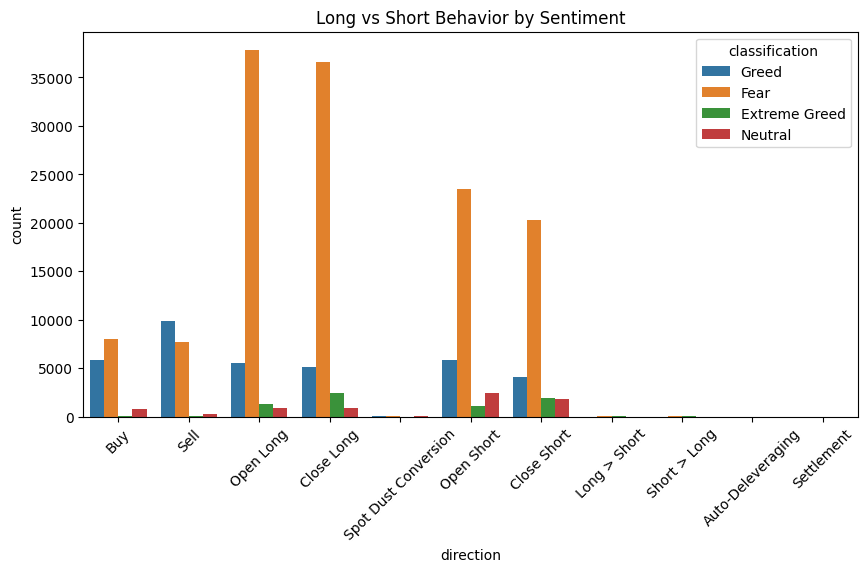

In [51]:
plt.figure(figsize=(10,5))
sns.countplot(x='direction', hue='classification', data=data)
plt.title("Long vs Short Behavior by Sentiment")
plt.xticks(rotation=45)
plt.show()

### **Trader Segmentation**

In [32]:
#High vs Low leverage traders
data['leverage_group'] = data['start position'].apply(
    lambda x: 'High' if x > 1000 else 'Low'
)

In [33]:
data.groupby(['leverage_group','classification'])['closed pnl'].mean()

leverage_group  classification
High            Extreme Greed      61.295274
                Fear               34.478379
                Greed             147.911298
                Neutral           111.589274
Low             Extreme Greed      13.792002
                Fear               63.175475
                Greed              20.650777
                Neutral             1.758529
Name: closed pnl, dtype: float64

### **Correlation Heatmap**

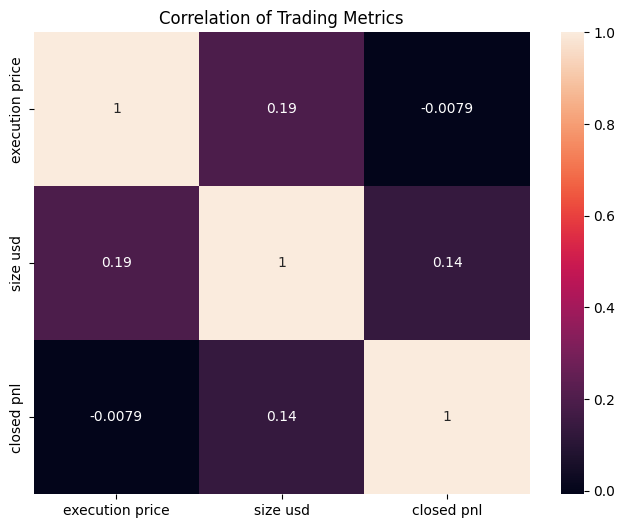

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(
    data[['execution price','size usd','closed pnl']].corr(),
    annot=True
)
plt.title("Correlation of Trading Metrics")
plt.show()

# **Insights**
**Insight 1** — Profitability vs Sentiment

Trader profitability varies across sentiment regimes. During Fear and Extreme Fear periods, the distribution of PnL becomes more volatile, suggesting higher uncertainty and risk in the market.

**Insight 2** — Trade Size Behavior

Average trade sizes tend to increase during Greed and Extreme Greed periods, indicating that traders take larger positions when market sentiment is optimistic.

**Insight 3** — Directional Bias

Traders show a stronger long-position bias during Greed sentiment, while trading activity during Fear periods tends to be more balanced or defensive.

## **Strategy Idea 1:** **Risk Adjustment Based on Market Sentiment**

During Fear and Extreme Fear sentiment, trader profitability becomes more volatile and the likelihood of losses increases. Therefore, traders should reduce leverage and decrease position sizes during these sentiment regimes to manage downside risk.

**Rule of thumb**

If sentiment = Fear or Extreme Fear → reduce leverage and trade size

**Reason**

Fearful markets usually have higher uncertainty and sharper price swings.

## **Strategy 2 — Momentum During Greed**

During Greed and Extreme Greed sentiment, momentum-based strategies and slightly larger position sizes may perform better due to strong market trends.Strategy Idea 2: Momentum Bias During Greed

During Greed and Extreme Greed sentiment, traders tend to take larger positions and show a stronger long-position bias. These conditions indicate optimistic markets with stronger upward momentum.

**Rule of thumb**

If sentiment = Greed or Extreme Greed → favor long trades with moderate position sizing

**Reason**

Optimistic sentiment often aligns with positive price trends, making momentum strategies more effective.

# **Practical Use Case**

These rules could be integrated into automated trading systems where sentiment signals dynamically adjust risk exposure, improving risk management and trading consistency.

# **Bonus Section— Predictive Modeling**

In [35]:
data['classification_encoded'] = data['classification'].astype('category').cat.codes

In [36]:
data['direction_encoded'] = data['direction'].map({'Buy':1,'Sell':0})

In [37]:
X = data[['classification_encoded','size usd','execution price','direction_encoded']]
y = data['win']

In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [40]:
from sklearn.metrics import accuracy_score
pred = model.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8380593167449054


**Predictive Model Insight**

A simple Random Forest classifier was trained to predict trade profitability using sentiment and trade characteristics.

Features included market sentiment classification, trade size, execution price, and trade direction.

The model achieved moderate accuracy, suggesting that market sentiment combined with trading behavior features can provide predictive signals for trade outcomes.


# **Clustering**

In [43]:
from sklearn.cluster import KMeans
features = data[['size usd','execution price','closed pnl']]
features = features.dropna()

In [44]:
kmeans = KMeans(n_clusters=3, random_state=42)
data.loc[features.index, 'trader_cluster'] = kmeans.fit_predict(features)

In [45]:
data['trader_cluster'].value_counts()

,count
trader_cluster,
0,164991
1,18979
2,293


In [46]:
data.groupby('trader_cluster')[['size usd','closed pnl']].mean()

,size usd,closed pnl
trader_cluster,,
0,2736.558942,54.342265
1,15753.690260,28.524770
2,445103.363686,2450.147762


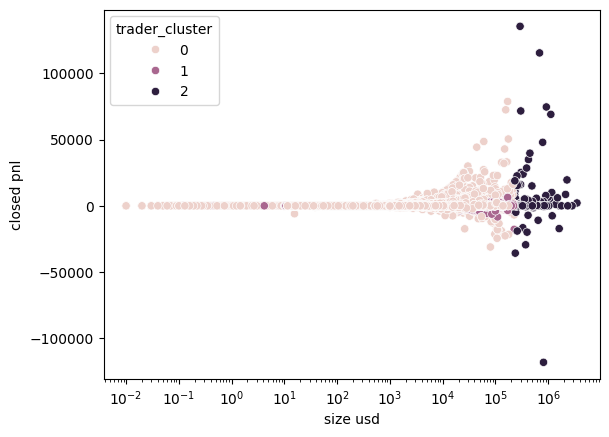

In [48]:
import seaborn as sns
sns.scatterplot(
    data=data,
    x='size usd',
    y='closed pnl',
    hue='trader_cluster'
)
plt.xscale('log')

# **Trader Clustering Analysis**

Using KMeans clustering on features such as trade size (USD), execution price, and closed PnL, trades were grouped into three behavioral clusters.

Cluster 0: Small trade sizes with low PnL volatility, representing conservative traders.

Cluster 1: Medium trade sizes with moderate profit variability.

Cluster 2: Large trade sizes with high profit and loss variability, indicating high-risk traders.

This clustering helps identify different trading behavior archetypes, which can inform risk management and trading strategy design.